# **Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

warnings.filterwarnings("ignore")

# **Load Dataset**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data/online_retail_II-Year 2010-2011.csv')

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
# Rentang Tanggal
# Format ditulis eksplisit (bulan/hari/tahun) agar hari & bulan tidak tertukar
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%Y %H:%M",
    errors="coerce"
)

print("Tanggal minimum :", df["InvoiceDate"].min())
print("Tanggal maksimum:", df["InvoiceDate"].max())
print("Tanggal gagal di-parse:", df["InvoiceDate"].isna().sum())

Tanggal minimum : 2010-12-01 08:26:00
Tanggal maksimum: 2011-12-09 12:50:00
Tanggal gagal di-parse: 0


# **EDA**

In [ ]:
print("=" * 60)
print("INFORMASI DATASET")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nKolom:")
print(df.columns.tolist())

print("\nInfo:")
df.info()

INFORMASI DATASET

Shape:
(541910, 8)

Kolom:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# Jumlah Data Unik
print("Jumlah invoice      :", df["Invoice"].nunique())
print("Jumlah StockCode    :", df["StockCode"].nunique())
print("Jumlah Description  :", df["Description"].nunique())
print("Jumlah Customer     :", df["Customer ID"].nunique())
print("Jumlah Country      :", df["Country"].nunique())

Jumlah invoice      : 25900
Jumlah StockCode    : 4070
Jumlah Description  : 4223
Jumlah Customer     : 4372
Jumlah Country      : 38


# Statistik deskriptif

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Invoice,541910,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541910,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540456,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541910.0,NaN,NaN,NaN,9.552234,-80995.0,1.0,3.0,10.0,80995.0,218.080957
InvoiceDate,541910,NaN,NaN,NaN,2011-07-04 13:35:22.342307584,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
Price,541910.0,NaN,NaN,NaN,4.611138,-11062.06,1.25,2.08,4.13,38970.0,96.759765
Customer ID,406830.0,NaN,NaN,NaN,15287.68416,12346.0,13953.0,15152.0,16791.0,18287.0,1713.603074
Country,541910,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df[["Quantity", "Price"]].describe()

,Quantity,Price
count,541910.000000,541910.000000
mean,9.552234,4.611138
std,218.080957,96.759765
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


# Distribusi negara

In [ ]:
country_summary = (
    df["Country"]
    .value_counts()
    .reset_index()
)

country_summary.columns = ["Country", "Jumlah_Baris"]

country_summary["Persentase"] = (
    country_summary["Jumlah_Baris"]
    / len(df)
    * 100
)

country_summary.head(15)

,Country,Jumlah_Baris,Persentase
0,United Kingdom,495478,91.431788
1,Germany,9495,1.752136
2,France,8558,1.579229
3,EIRE,8196,1.512428
4,Spain,2533,0.467421
5,Netherlands,2371,0.437527
6,Belgium,2069,0.381798
7,Switzerland,2002,0.369434
8,Portugal,1519,0.280305
9,Australia,1259,0.232326


# Top 10 negara berdasarkan jumlah baris transaksi

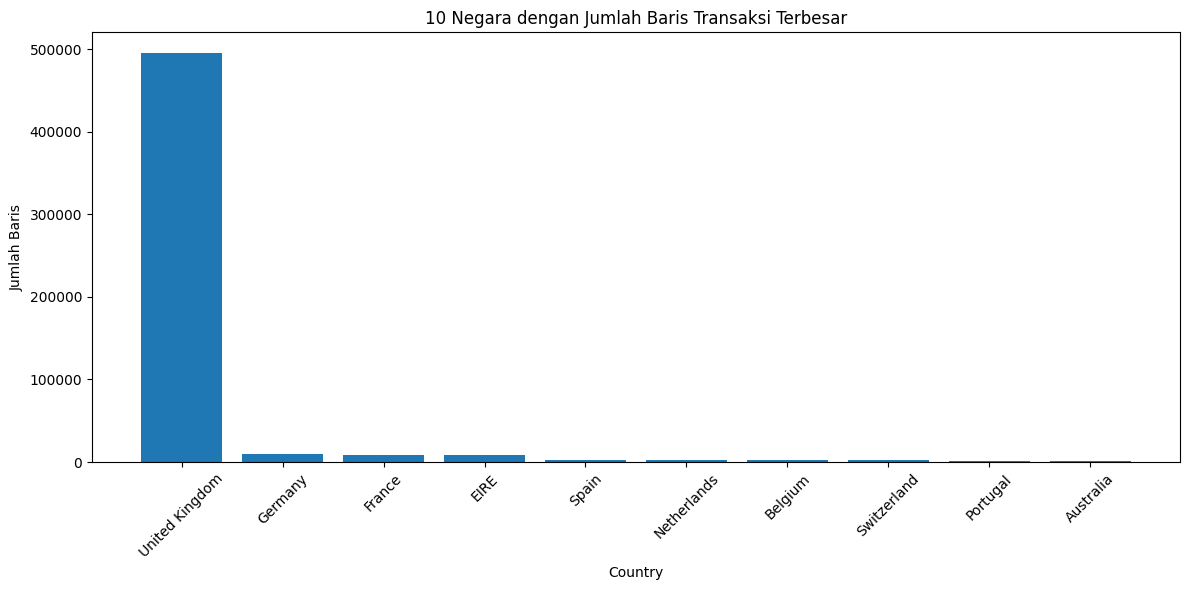

In [ ]:
top_country = country_summary.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_country["Country"],
    top_country["Jumlah_Baris"]
)

plt.title("10 Negara dengan Jumlah Baris Transaksi Terbesar")
plt.xlabel("Country")
plt.ylabel("Jumlah Baris")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Catatan:** 91% baris transaksi berasal dari **United Kingdom**. Analisis ini memakai data dari **semua negara**, sehingga pola asosiasi yang ditemukan pada dasarnya mencerminkan perilaku pelanggan UK. Alternatifnya, analisis bisa difokuskan hanya pada UK agar pola belanjanya lebih homogen.

# Analisis transaksi per bulan

In [ ]:
monthly_transaction = (
    df.dropna(subset=["InvoiceDate"])
      .assign(
          Month=lambda x:
          x["InvoiceDate"].dt.to_period("M").astype(str)
      )
      .groupby("Month")["Invoice"]
      .nunique()
      .reset_index(name="Jumlah_Invoice")
)

monthly_transaction.head()

,Month,Jumlah_Invoice
0,2010-12,2025
1,2011-01,1476
2,2011-02,1393
3,2011-03,1983
4,2011-04,1744


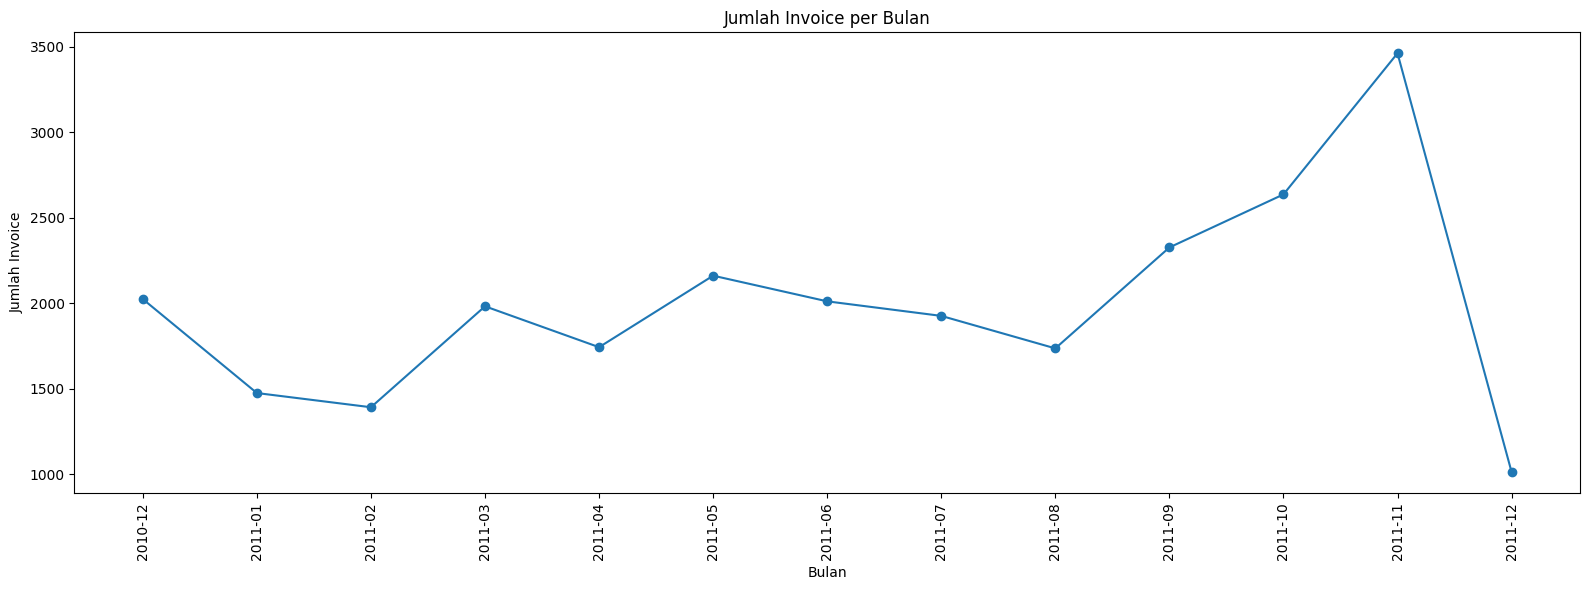

In [ ]:
plt.figure(figsize=(16, 6))

plt.plot(
    monthly_transaction["Month"],
    monthly_transaction["Jumlah_Invoice"],
    marker="o"
)

plt.title("Jumlah Invoice per Bulan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Invoice")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

**Catatan:** data Desember 2011 hanya tersedia sampai **9 Desember 2011**, sehingga penurunan jumlah invoice di bulan terakhir **bukan tren penurunan yang sebenarnya**, melainkan karena data bulan tersebut tidak lengkap.

# **Missing Values**

In [ ]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Persentase": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values("Missing", ascending=False)

missing

,Missing,Persentase
Customer ID,135080,24.926648
Description,1454,0.268310
StockCode,0,0.000000
Invoice,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
Price,0,0.000000
Country,0,0.000000


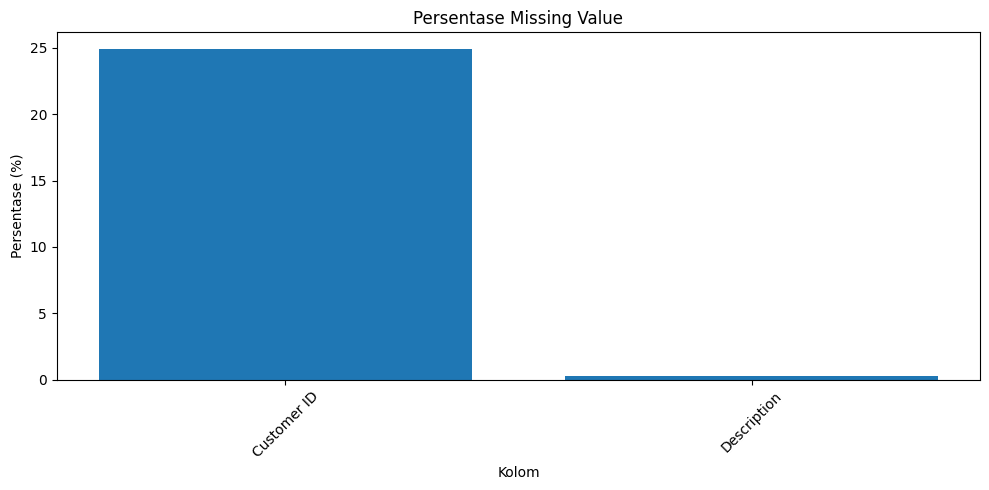

In [ ]:
missing_plot = missing[missing["Missing"] > 0]

plt.figure(figsize=(10, 5))

plt.bar(
    missing_plot.index.astype(str),
    missing_plot["Persentase"]
)

plt.title("Persentase Missing Value")
plt.ylabel("Persentase (%)")
plt.xlabel("Kolom")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Keputusan terkait missing value:**
- **Customer ID (24,9%) tidak dihapus.** Market basket analysis memakai *invoice* sebagai unit analisis, bukan pelanggan. Identitas pelanggan tidak dibutuhkan untuk membentuk keranjang belanja, sehingga menghapus baris ini justru akan membuang ±25% transaksi yang valid.
- **Description (0,27%) dihapus** pada tahap cleaning karena baris tanpa deskripsi umumnya merupakan baris penyesuaian stok dengan harga 0, bukan penjualan produk.

In [ ]:
# Duplicate Data
duplicate_count = df.duplicated().sum()

print("Jumlah duplicate:", duplicate_count)
print("Persentase duplicate:",
      duplicate_count / len(df) * 100)

Jumlah duplicate: 5268
Persentase duplicate: 0.9721171412227123


**Keputusan terkait data duplikat:** baris duplikat **tidak dihapus secara eksplisit**. Pada tahap preprocessing, setiap invoice diubah menjadi *himpunan* produk (`set()`), sehingga produk yang muncul lebih dari sekali dalam satu invoice otomatis hanya dihitung satu kali. Artinya, duplikat tidak memengaruhi nilai support, confidence, maupun lift.

In [ ]:
# Analisis Retur
df["Invoice"] = df["Invoice"].astype(str).str.strip()

cancel_mask = df["Invoice"].str.upper().str.startswith("C")

print("Jumlah baris cancellation :", cancel_mask.sum())
print(
    "Persentase cancellation   :",
    cancel_mask.mean() * 100
)

Jumlah baris cancellation : 9288
Persentase cancellation   : 1.7139377387389048


In [ ]:
# Harga & qty tidak valid
print("Quantity < 0 :", (df["Quantity"] < 0).sum())
print("Quantity = 0 :", (df["Quantity"] == 0).sum())

print("Price < 0    :", (df["Price"] < 0).sum())
print("Price = 0    :", (df["Price"] == 0).sum())
print("Price <= 0   :", (df["Price"] <= 0).sum())

Quantity < 0 : 10624
Quantity = 0 : 0
Price < 0    : 2
Price = 0    : 2515
Price <= 0   : 2517


# **Data Cleaning**

In [ ]:
data = df.copy()

print("Data awal:", data.shape)

Data awal: (541910, 8)


In [ ]:
# Normalisasi String
data["Invoice"] = (
    data["Invoice"]
    .astype(str)
    .str.strip()
)

data["StockCode"] = (
    data["StockCode"]
    .astype(str)
    .str.strip()
    .str.upper()   # samakan kapitalisasi kode produk
)

data["Description"] = (
    data["Description"]
    .astype("string")
    .str.strip()
    .str.upper()
)

data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
# Untuk mencatat proses cleaning
cleaning_log = []

def log_cleaning(step, dataframe):
    cleaning_log.append({
        "Tahap": step,
        "Jumlah_Baris": len(dataframe),
        "Jumlah_Invoice": dataframe["Invoice"].nunique(),
        "Jumlah_Produk": dataframe["StockCode"].nunique()
    })

log_cleaning("Data awal", data)

In [ ]:
# Menghapus Description Null
data = data[
    data["Description"].notna()
].copy()

log_cleaning(
    "Hapus Description null",
    data
)

print(data.shape)

(540456, 8)


In [ ]:
# Menghapus Transaksi yang di cancel
data = data[
    ~data["Invoice"]
    .str.upper()
    .str.startswith("C")
].copy()

log_cleaning(
    "Hapus cancellation",
    data
)

print(data.shape)

(531168, 8)


In [ ]:
# Filter Harga
data = data[
    data["Price"] > 0
].copy()

log_cleaning(
    "Price > 0",
    data
)

print(data.shape)

(530105, 8)


In [ ]:
# Filter qty
data = data[
    data["Quantity"] > 0
].copy()

log_cleaning(
    "Quantity > 0",
    data
)

print(data.shape)

(530105, 8)


**Catatan:** filter `Quantity > 0` tidak menghapus baris apa pun karena seluruh baris dengan quantity negatif sudah terbuang pada tahap sebelumnya (transaksi cancellation dan `Price > 0`). Tahap ini tetap dipertahankan sebagai pengaman (*sanity check*).

In [ ]:
# Menghapus kode non produk
non_product_codes = {
    "POST",          # postage
    "DOT",           # dotcom postage
    "M",             # manual
    "D",             # discount
    "BANK CHARGES",
    "C2",            # carriage
    "AMAZONFEE",
    "ADJUST",
    "ADJUST2",
    "PADS",
    "TEST001",
    "TEST002",
    "B",
    "S"
}

mask_non_product = (
    data["StockCode"].isin(non_product_codes)
)

mask_gift_voucher = (
    data["StockCode"]
    .str.lower()
    .str.startswith("gift_0001_", na=False)
)

print(
    "Non-product rows:",
    mask_non_product.sum()
)

print(
    "Gift voucher rows:",
    mask_gift_voucher.sum()
)

Non-product rows: 2316
Gift voucher rows: 31


In [ ]:
data = data[
    ~(mask_non_product | mask_gift_voucher)
].copy()

log_cleaning(
    "Hapus service/admin/test/voucher",
    data
)

print("Ukuran data clean:", data.shape)
print(
    "Invoice:",
    data["Invoice"].nunique()
)
print(
    "Produk:",
    data["StockCode"].nunique()
)

Ukuran data clean: (527758, 8)
Invoice: 19773
Produk: 3798


# **Log Proses Cleaning**

In [ ]:
cleaning_summary = pd.DataFrame(cleaning_log)

cleaning_summary

,Tahap,Jumlah_Baris,Jumlah_Invoice,Jumlah_Produk
0,Data awal,541910,25900,3958
1,Hapus Description null,540456,24446,3848
2,Hapus cancellation,531168,20610,3833
3,Price > 0,530105,19960,3812
4,Quantity > 0,530105,19960,3812
5,Hapus service/admin/test/voucher,527758,19773,3798


In [ ]:
# Persentase Data yang dibuang
initial_rows = len(df)
final_rows = len(data)

removed_rows = initial_rows - final_rows

removed_percent = (
    removed_rows /
    initial_rows
    * 100
)

print("Data awal       :", initial_rows)
print("Data akhir      :", final_rows)
print("Data dibuang    :", removed_rows)
print(
    f"Persentase      : {removed_percent:.2f}%"
)

Data awal       : 541910
Data akhir      : 527758
Data dibuang    : 14152
Persentase      : 2.61%


In [ ]:
product_lookup_df = (
    data.groupby(
        ["StockCode", "Description"]
    )
    .size()
    .reset_index(name="frequency")
    .sort_values(
        ["StockCode", "frequency"],
        ascending=[True, False]
    )
    .drop_duplicates("StockCode")
)

product_lookup = dict(
    zip(
        product_lookup_df["StockCode"],
        product_lookup_df["Description"]
    )
)

len(product_lookup)

3798

# **EDA 2 (Setelah Cleaning)**

# Produk paling Populer Berdasarkan Invoice

In [ ]:
top_products = (
    data.groupby("StockCode")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
    .reset_index(name="Jumlah_Invoice")
)

top_products["Description"] = (
    top_products["StockCode"]
    .map(product_lookup)
)

total_invoice = (
    data["Invoice"].nunique()
)

top_products["Support"] = (
    top_products["Jumlah_Invoice"]
    / total_invoice
)

top_products[
    [
        "StockCode",
        "Description",
        "Jumlah_Invoice",
        "Support"
    ]
]

,StockCode,Description,Jumlah_Invoice,Support
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2265,0.114550
1,85099B,JUMBO BAG RED RETROSPOT,2089,0.105649
2,22423,REGENCY CAKESTAND 3 TIER,1988,0.100541
3,47566,PARTY BUNTING,1685,0.085217
4,20725,LUNCH BAG RED RETROSPOT,1565,0.079148
5,84879,ASSORTED COLOUR BIRD ORNAMENT,1455,0.073585
6,22197,POPCORN HOLDER,1392,0.070399
7,22720,SET OF 3 CAKE TINS PANTRY DESIGN,1385,0.070045
8,21212,PACK OF 72 RETROSPOT CAKE CASES,1320,0.066758
9,22383,LUNCH BAG SUKI DESIGN,1284,0.064937


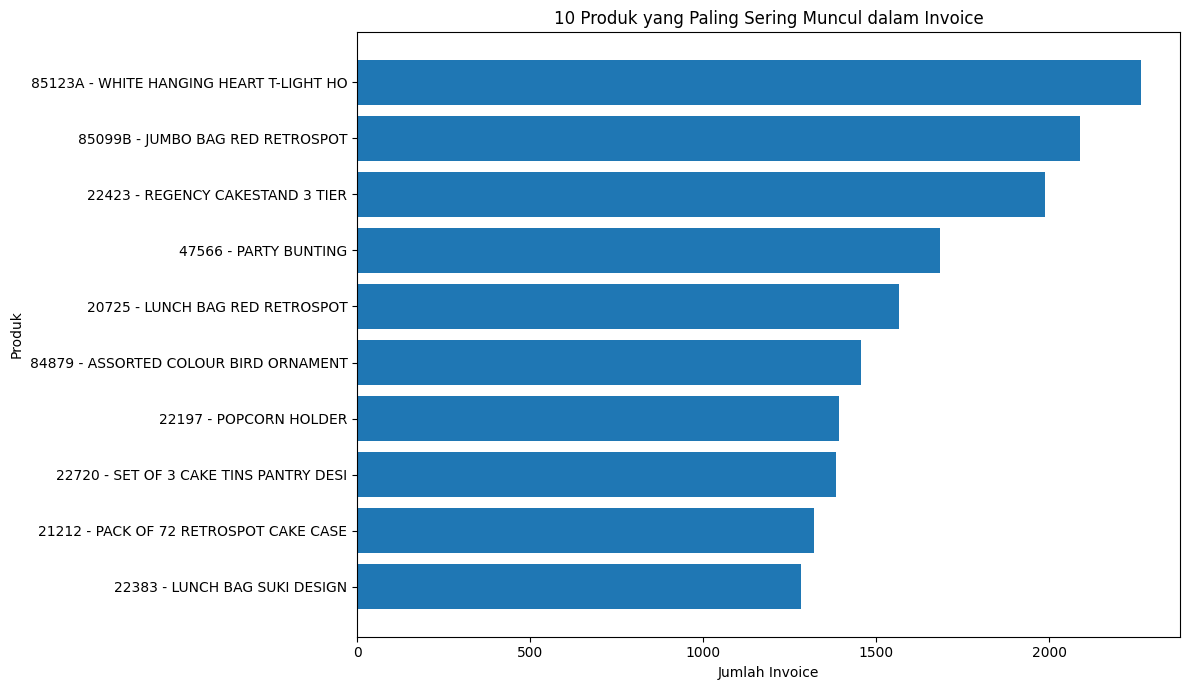

In [ ]:
plot_product = top_products.head(10).copy()

labels = (
    plot_product["StockCode"]
    + " - "
    + plot_product["Description"].str[:30]
)

plt.figure(figsize=(12, 7))

plt.barh(
    labels[::-1],
    plot_product["Jumlah_Invoice"][::-1]
)

plt.title("10 Produk yang Paling Sering Muncul dalam Invoice")
plt.xlabel("Jumlah Invoice")
plt.ylabel("Produk")

plt.tight_layout()
plt.show()

# Analisis Ukuran Basket

In [ ]:
basket_size = (
    data.groupby("Invoice")["StockCode"]
    .nunique()
)

basket_size.describe(
    percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
)

,StockCode
count,19773.000000
mean,26.161281
std,47.019058
min,1.000000
25%,6.000000
50%,15.000000
75%,29.000000
90%,52.000000
95%,75.000000
99%,218.000000


In [ ]:
print(
    "Rata-rata produk / invoice :",
    basket_size.mean()
)

print(
    "Median produk / invoice    :",
    basket_size.median()
)

print(
    "Maksimum produk / invoice  :",
    basket_size.max()
)

Rata-rata produk / invoice : 26.1612805340616
Median produk / invoice    : 15.0
Maksimum produk / invoice  : 1106


In [ ]:
# Invoice dengan ukuran basket ekstrem (di atas persentil 99)
p99 = basket_size.quantile(0.99)
large_invoices = basket_size[basket_size > p99].index

print(f"Batas persentil 99      : {p99:.0f} produk/invoice")
print("Jumlah invoice > P99    :", len(large_invoices))
print(f"Persentase dari invoice : {len(large_invoices) / len(basket_size) * 100:.2f}%")

Batas persentil 99      : 218 produk/invoice
Jumlah invoice > P99    : 197
Persentase dari invoice : 1.00%


**Catatan:** sebagian kecil invoice berisi ratusan hingga lebih dari seribu produk berbeda. Invoice seperti ini kemungkinan besar berasal dari pembeli grosir/reseller yang membeli hampir seluruh katalog, sehingga berpotensi memunculkan asosiasi semu. Invoice tersebut **tetap dipertahankan** pada model utama, namun pengaruhnya diuji pada bagian **Uji Sensitivitas** setelah pemodelan.

# **Preprocessing**

In [ ]:
transactions_series = (
    data.groupby(
        "Invoice",
        sort=False
    )["StockCode"]
    .agg(lambda x: list(set(x)))
)

invoice_ids = (
    transactions_series.index
)

transactions = (
    transactions_series.tolist()
)

print(
    "Jumlah transaksi:",
    len(transactions)
)

print(
    "Contoh transaksi:"
)

print(transactions[0][:20])

Jumlah transaksi: 19773
Contoh transaksi:
['84029G', '21730', '22752', '85123A', '71053', '84029E', '84406B']


In [ ]:
# Transaction Encoder
te = TransactionEncoder()

te_array = (
    te.fit(transactions)
      .transform(
          transactions,
          sparse=True
      )
)

basket = (
    pd.DataFrame.sparse.from_spmatrix(
        te_array,
        index=invoice_ids,
        columns=te.columns_
    )
)

print(
    "Shape basket:",
    basket.shape
)

basket.head()

Shape basket: (19773, 3798)


,10002,10080,10120,10123C,10124A,10124G,10125,10133,10135,11001,...,90214W,90214Y,90214Z,DCGS0003,DCGS0004,DCGS0069,DCGS0070,DCGS0076,DCGSSBOY,DCGSSGIRL
Invoice,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
basket = basket.astype(
    pd.SparseDtype(bool, False)
)

print(
    basket.dtypes.head()
)

print(
    "Shape:",
    basket.shape
)

10002     Sparse[bool, 0]
10080     Sparse[bool, 0]
10120     Sparse[bool, 0]
10123C    Sparse[bool, 0]
10124A    Sparse[bool, 0]
dtype: object
Shape: (19773, 3798)


# **Penentuan Parameter**

- **`MIN_SUPPORT = 0.01`** → suatu itemset harus muncul di minimal 1% invoice (±198 dari 19.773 invoice). Dengan rata-rata support produk tunggal yang rendah (produk terpopuler hanya ±11%), nilai 1% cukup rendah untuk menangkap pola kombinasi produk, tetapi cukup tinggi untuk membuang kombinasi yang terjadi secara kebetulan.
- **`MIN_CONFIDENCE = 0.50`** → rule hanya dipertahankan jika minimal 50% pembeli antecedent juga membeli consequent, sehingga rule cukup kuat untuk dijadikan dasar rekomendasi.
- **`lift > 1`** → hanya rule dengan asosiasi positif (pembelian antecedent benar-benar meningkatkan peluang pembelian consequent).

Pemilihan nilai ini diuji pada bagian **Uji Sensitivitas**.

# **Modelling**

In [ ]:
MIN_SUPPORT = 0.01

frequent_itemsets = fpgrowth(
    basket,
    min_support=MIN_SUPPORT,
    use_colnames=True
)

frequent_itemsets = (
    frequent_itemsets
    .sort_values(
        "support",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Jumlah frequent itemsets:",
    len(frequent_itemsets)
)

frequent_itemsets.head(20)

Jumlah frequent itemsets: 2026


,support,itemsets
0,0.114550,(85123A)
1,0.105649,(85099B)
2,0.100541,(22423)
3,0.085217,(47566)
4,0.079148,(20725)
5,0.073585,(84879)
6,0.070399,(22197)
7,0.070045,(22720)
8,0.066758,(21212)
9,0.064937,(22383)


In [ ]:
frequent_itemsets["length"] = (
    frequent_itemsets["itemsets"]
    .apply(len)
)

frequent_itemsets[
    "length"
].value_counts().sort_index()

,count
length,
1,829
2,910
3,261
4,25
5,1


In [ ]:
# frequent itemset terbesar
frequent_itemsets.head(30)

,support,itemsets,length
0,0.114550,(85123A),1
1,0.105649,(85099B),1
2,0.100541,(22423),1
3,0.085217,(47566),1
4,0.079148,(20725),1
5,0.073585,(84879),1
6,0.070399,(22197),1
7,0.070045,(22720),1
8,0.066758,(21212),1
9,0.064937,(22383),1


In [ ]:
MIN_CONFIDENCE = 0.50

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=MIN_CONFIDENCE
)

In [ ]:
rules = rules[
    rules["lift"] > 1
].copy()

rules = (
    rules
    .sort_values(
        ["lift", "confidence", "support"],
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Jumlah association rules:",
    len(rules)
)

rules.head()

Jumlah association rules: 962


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(22916),"(22918, 22917)",0.011986,0.010873,0.010267,0.856540,78.773800,1.0,0.010136,6.894794,0.999283,0.815261,0.854963,0.900363
1,"(22918, 22917)",(22916),0.010873,0.011986,0.010267,0.944186,78.773800,1.0,0.010136,17.701917,0.998159,0.815261,0.943509,0.900363
2,"(22918, 22916)",(22917),0.010772,0.012138,0.010267,0.953052,78.519542,1.0,0.010136,21.041466,0.998015,0.812000,0.952475,0.899442
3,(22917),"(22918, 22916)",0.012138,0.010772,0.010267,0.845833,78.519542,1.0,0.010136,6.416612,0.999395,0.812000,0.844155,0.899442
4,"(22920, 22916)",(22917),0.010621,0.012138,0.010115,0.952381,78.464286,1.0,0.009986,20.745107,0.997853,0.800000,0.951796,0.892857


# **Menghapus Rules Dobel (Simetris)**

Rule **A → B** dan **B → A** memiliki support dan lift yang sama persis, hanya confidence-nya yang berbeda. Agar jumlah rules tidak terlihat lebih banyak dari pola yang sebenarnya, untuk setiap pasangan antecedent–consequent hanya disimpan **satu rule dengan confidence tertinggi**.

In [ ]:
rules["pair_key"] = rules.apply(
    lambda r: frozenset([r["antecedents"], r["consequents"]]),
    axis=1
)

rules_unique = (
    rules
    .sort_values(["confidence", "lift"], ascending=False)
    .drop_duplicates("pair_key")
    .drop(columns="pair_key")
    .sort_values(["lift", "confidence", "support"], ascending=False)
    .reset_index(drop=True)
)

rules = rules.drop(columns="pair_key")

print("Rules sebelum dedup :", len(rules))
print("Rules setelah dedup :", len(rules_unique))

Rules sebelum dedup : 962
Rules setelah dedup : 870


In [ ]:
# Mengubah StockCode menjadi produk
def itemset_to_code(itemset):
    return ", ".join(
        sorted(
            list(itemset)
        )
    )


def itemset_to_description(itemset):
    descriptions = []

    for code in sorted(list(itemset)):
        desc = product_lookup.get(
            code,
            code
        )

        descriptions.append(desc)

    return ", ".join(descriptions)

In [ ]:
rules_display = rules.copy()

rules_display[
    "Antecedent_Code"
] = rules_display[
    "antecedents"
].apply(itemset_to_code)

rules_display[
    "Consequent_Code"
] = rules_display[
    "consequents"
].apply(itemset_to_code)

rules_display[
    "Antecedent"
] = rules_display[
    "antecedents"
].apply(itemset_to_description)

rules_display[
    "Consequent"
] = rules_display[
    "consequents"
].apply(itemset_to_description)

In [ ]:
rules_result = rules_display[
    [
        "Antecedent_Code",
        "Antecedent",
        "Consequent_Code",
        "Consequent",
        "support",
        "confidence",
        "lift"
    ]
].copy()

rules_result.head(30)

,Antecedent_Code,Antecedent,Consequent_Code,Consequent,support,confidence,lift
0,22916,HERB MARKER THYME,"22917, 22918","HERB MARKER ROSEMARY, HERB MARKER PARSLEY",0.010267,0.856540,78.773800
1,"22917, 22918","HERB MARKER ROSEMARY, HERB MARKER PARSLEY",22916,HERB MARKER THYME,0.010267,0.944186,78.773800
2,"22916, 22918","HERB MARKER THYME, HERB MARKER PARSLEY",22917,HERB MARKER ROSEMARY,0.010267,0.953052,78.519542
3,22917,HERB MARKER ROSEMARY,"22916, 22918","HERB MARKER THYME, HERB MARKER PARSLEY",0.010267,0.845833,78.519542
4,"22916, 22920","HERB MARKER THYME, HERB MARKER BASIL",22917,HERB MARKER ROSEMARY,0.010115,0.952381,78.464286
5,22917,HERB MARKER ROSEMARY,"22916, 22920","HERB MARKER THYME, HERB MARKER BASIL",0.010115,0.833333,78.464286
6,"22917, 22920","HERB MARKER ROSEMARY, HERB MARKER BASIL",22916,HERB MARKER THYME,0.010115,0.934579,77.972318
7,22916,HERB MARKER THYME,"22917, 22920","HERB MARKER ROSEMARY, HERB MARKER BASIL",0.010115,0.843882,77.972318
8,22916,HERB MARKER THYME,22917,HERB MARKER ROSEMARY,0.011177,0.932489,76.825475
9,22917,HERB MARKER ROSEMARY,22916,HERB MARKER THYME,0.011177,0.920833,76.825475


In [ ]:
# Tabel hasil versi tanpa rules dobel
def to_result(df_rules):
    out = pd.DataFrame({
        "Antecedent_Code": df_rules["antecedents"].apply(itemset_to_code),
        "Antecedent":      df_rules["antecedents"].apply(itemset_to_description),
        "Consequent_Code": df_rules["consequents"].apply(itemset_to_code),
        "Consequent":      df_rules["consequents"].apply(itemset_to_description),
        "support":         df_rules["support"],
        "confidence":      df_rules["confidence"],
        "lift":            df_rules["lift"],
    })
    return out.reset_index(drop=True)

rules_result_unique = to_result(rules_unique)

rules_result_unique.head(20)

,Antecedent_Code,Antecedent,Consequent_Code,Consequent,support,confidence,lift
0,"22917, 22918","HERB MARKER ROSEMARY, HERB MARKER PARSLEY",22916,HERB MARKER THYME,0.010267,0.944186,78.773800
1,"22916, 22918","HERB MARKER THYME, HERB MARKER PARSLEY",22917,HERB MARKER ROSEMARY,0.010267,0.953052,78.519542
2,"22916, 22920","HERB MARKER THYME, HERB MARKER BASIL",22917,HERB MARKER ROSEMARY,0.010115,0.952381,78.464286
3,"22917, 22920","HERB MARKER ROSEMARY, HERB MARKER BASIL",22916,HERB MARKER THYME,0.010115,0.934579,77.972318
4,22916,HERB MARKER THYME,22917,HERB MARKER ROSEMARY,0.011177,0.932489,76.825475
5,"22916, 22917","HERB MARKER THYME, HERB MARKER ROSEMARY",22918,HERB MARKER PARSLEY,0.010267,0.918552,76.313149
6,22916,HERB MARKER THYME,22918,HERB MARKER PARSLEY,0.010772,0.898734,74.666684
7,22918,HERB MARKER PARSLEY,22917,HERB MARKER ROSEMARY,0.010873,0.903361,74.425683
8,"22916, 22917","HERB MARKER THYME, HERB MARKER ROSEMARY",22920,HERB MARKER BASIL,0.010115,0.904977,73.942635
9,22918,HERB MARKER PARSLEY,22919,HERB MARKER MINT,0.010722,0.890756,73.387185


In [ ]:
# Rules dengan lift tertinggi
top_lift = (
    rules_result
    .sort_values(
        "lift",
        ascending=False
    )
    .head(20)
)

top_lift

,Antecedent_Code,Antecedent,Consequent_Code,Consequent,support,confidence,lift
0,22916,HERB MARKER THYME,"22917, 22918","HERB MARKER ROSEMARY, HERB MARKER PARSLEY",0.010267,0.856540,78.773800
1,"22917, 22918","HERB MARKER ROSEMARY, HERB MARKER PARSLEY",22916,HERB MARKER THYME,0.010267,0.944186,78.773800
3,22917,HERB MARKER ROSEMARY,"22916, 22918","HERB MARKER THYME, HERB MARKER PARSLEY",0.010267,0.845833,78.519542
2,"22916, 22918","HERB MARKER THYME, HERB MARKER PARSLEY",22917,HERB MARKER ROSEMARY,0.010267,0.953052,78.519542
5,22917,HERB MARKER ROSEMARY,"22916, 22920","HERB MARKER THYME, HERB MARKER BASIL",0.010115,0.833333,78.464286
4,"22916, 22920","HERB MARKER THYME, HERB MARKER BASIL",22917,HERB MARKER ROSEMARY,0.010115,0.952381,78.464286
6,"22917, 22920","HERB MARKER ROSEMARY, HERB MARKER BASIL",22916,HERB MARKER THYME,0.010115,0.934579,77.972318
7,22916,HERB MARKER THYME,"22917, 22920","HERB MARKER ROSEMARY, HERB MARKER BASIL",0.010115,0.843882,77.972318
8,22916,HERB MARKER THYME,22917,HERB MARKER ROSEMARY,0.011177,0.932489,76.825475
9,22917,HERB MARKER ROSEMARY,22916,HERB MARKER THYME,0.011177,0.920833,76.825475


In [ ]:
# Rules dengan support tertinggi
top_support = (
    rules_result
    .sort_values(
        ["support", "confidence", "lift"],
        ascending=False
    )
    .head(20)
)

top_support

,Antecedent_Code,Antecedent,Consequent_Code,Consequent,support,confidence,lift
925,22386,JUMBO BAG PINK POLKADOT,85099B,JUMBO BAG RED RETROSPOT,0.041724,0.677340,6.411222
397,22697,GREEN REGENCY TEACUP AND SAUCER,22699,ROSES REGENCY TEACUP AND SAUCER,0.038790,0.757157,14.057525
398,22699,ROSES REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,0.038790,0.720188,14.057525
938,21931,JUMBO STORAGE BAG SUKI,85099B,JUMBO BAG RED RETROSPOT,0.036616,0.611486,5.787900
947,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,85099B,JUMBO BAG RED RETROSPOT,0.034390,0.578723,5.477787
924,22383,LUNCH BAG SUKI DESIGN,20725,LUNCH BAG RED RETROSPOT,0.033126,0.510125,6.445172
926,20727,LUNCH BAG BLACK SKULL.,20725,LUNCH BAG RED RETROSPOT,0.032418,0.503535,6.361915
471,22726,ALARM CLOCK BAKELIKE GREEN,22727,ALARM CLOCK BAKELIKE RED,0.032367,0.653061,12.286374
470,22727,ALARM CLOCK BAKELIKE RED,22726,ALARM CLOCK BAKELIKE GREEN,0.032367,0.608944,12.286374
296,22698,PINK REGENCY TEACUP AND SAUCER,22697,GREEN REGENCY TEACUP AND SAUCER,0.031963,0.826144,16.125707


In [ ]:
# Rules dengan confidence tertinggi
top_confidence = (
    rules_result
    .sort_values(
        ["confidence", "lift", "support"],
        ascending=False
    )
    .head(20)
)

top_confidence

,Antecedent_Code,Antecedent,Consequent_Code,Consequent,support,confidence,lift
2,"22916, 22918","HERB MARKER THYME, HERB MARKER PARSLEY",22917,HERB MARKER ROSEMARY,0.010267,0.953052,78.519542
4,"22916, 22920","HERB MARKER THYME, HERB MARKER BASIL",22917,HERB MARKER ROSEMARY,0.010115,0.952381,78.464286
34,"23170, 23172","REGENCY TEA PLATE ROSES, REGENCY TEA PLATE PINK",23171,REGENCY TEA PLATE GREEN,0.012896,0.947955,49.196645
1,"22917, 22918","HERB MARKER ROSEMARY, HERB MARKER PARSLEY",22916,HERB MARKER THYME,0.010267,0.944186,78.773800
6,"22917, 22920","HERB MARKER ROSEMARY, HERB MARKER BASIL",22916,HERB MARKER THYME,0.010115,0.934579,77.972318
8,22916,HERB MARKER THYME,22917,HERB MARKER ROSEMARY,0.011177,0.932489,76.825475
79,"22577, 22579","WOODEN HEART CHRISTMAS SCANDINAVIAN, WOODEN TR...",22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,0.011683,0.927711,35.827396
9,22917,HERB MARKER ROSEMARY,22916,HERB MARKER THYME,0.011177,0.920833,76.825475
246,"20719, 20723, 22356","WOODLAND CHARLOTTE BAG, STRAWBERRY CHARLOTTE B...",20724,RED RETROSPOT CHARLOTTE BAG,0.012239,0.920152,17.630007
248,"20719, 20723, 22355, 22356","WOODLAND CHARLOTTE BAG, STRAWBERRY CHARLOTTE B...",20724,RED RETROSPOT CHARLOTTE BAG,0.010317,0.918919,17.606380


# **Rules Lintas Lini Produk**

Rules dengan lift tertinggi didominasi oleh varian dari produk yang sama (misalnya HERB MARKER thyme, rosemary, parsley, basil), yaitu produk yang memang dijual sebagai satu seri. Temuan ini wajar, tetapi kurang informatif untuk strategi *cross-selling*.

Untuk menemukan asosiasi antar lini produk yang berbeda, digunakan pendekatan heuristik sederhana: rule dianggap **lintas lini produk** jika deskripsi antecedent dan consequent **tidak memiliki kata kunci yang sama** (setelah mengabaikan kata warna dan kata umum).

In [ ]:
import re

GENERIC_WORDS = {
    # warna
    "RED", "PINK", "BLUE", "GREEN", "WHITE", "BLACK", "IVORY", "CREAM",
    "YELLOW", "PURPLE", "ORANGE", "GREY", "GOLD", "SILVER", "BROWN",
    "ROSES", "ROSE",
    # kata umum
    "OF", "AND", "THE", "SET", "WITH", "IN", "A", "DESIGN", "SMALL",
    "LARGE", "MINI", "PACK", "VINTAGE", "RETROSPOT", "POLKADOT", "SUKI",
}

def keywords(itemset):
    words = set()
    for code in itemset:
        desc = product_lookup.get(code, code)
        tokens = re.findall(r"[A-Z]+", str(desc).upper())
        words |= {t for t in tokens if len(t) > 2 and t not in GENERIC_WORDS}
    return words

rules_unique["cross_line"] = rules_unique.apply(
    lambda r: len(keywords(r["antecedents"]) & keywords(r["consequents"])) == 0,
    axis=1
)

cross_line_rules = to_result(
    rules_unique[rules_unique["cross_line"]]
    .sort_values(["lift", "confidence"], ascending=False)
)

print("Jumlah rules lintas lini produk:", len(cross_line_rules))
cross_line_rules.head(20)

Jumlah rules lintas lini produk: 3


,Antecedent_Code,Antecedent,Consequent_Code,Consequent,support,confidence,lift
0,22381,TOY TIDY PINK POLKADOT,22379,RECYCLING BAG RETROSPOT,0.013756,0.579957,15.330878
1,21791,VINTAGE HEADS AND TAILS CARD GAME,21790,VINTAGE SNAP CARDS,0.017296,0.563427,12.030924
2,22381,TOY TIDY PINK POLKADOT,85099B,JUMBO BAG RED RETROSPOT,0.012340,0.520256,4.924375


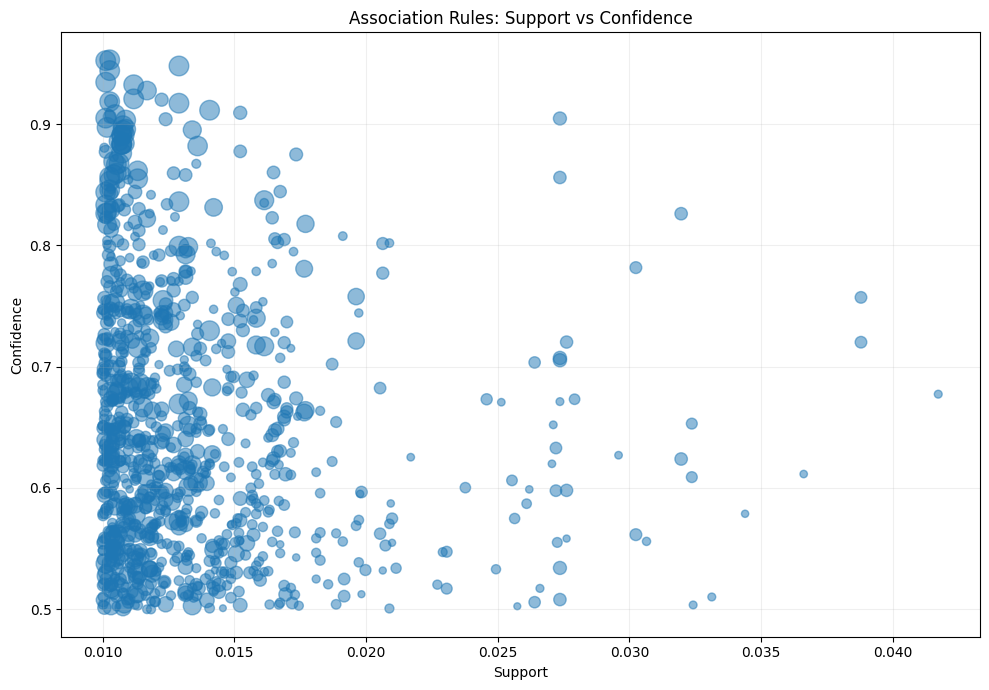

In [ ]:
# Visualisasi Support vs Confidence
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    rules["support"],
    rules["confidence"],
    s=np.clip(
        rules["lift"] * 5,
        10,
        200
    ),
    alpha=0.5
)

plt.title(
    "Association Rules: Support vs Confidence"
)

plt.xlabel("Support")
plt.ylabel("Confidence")

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

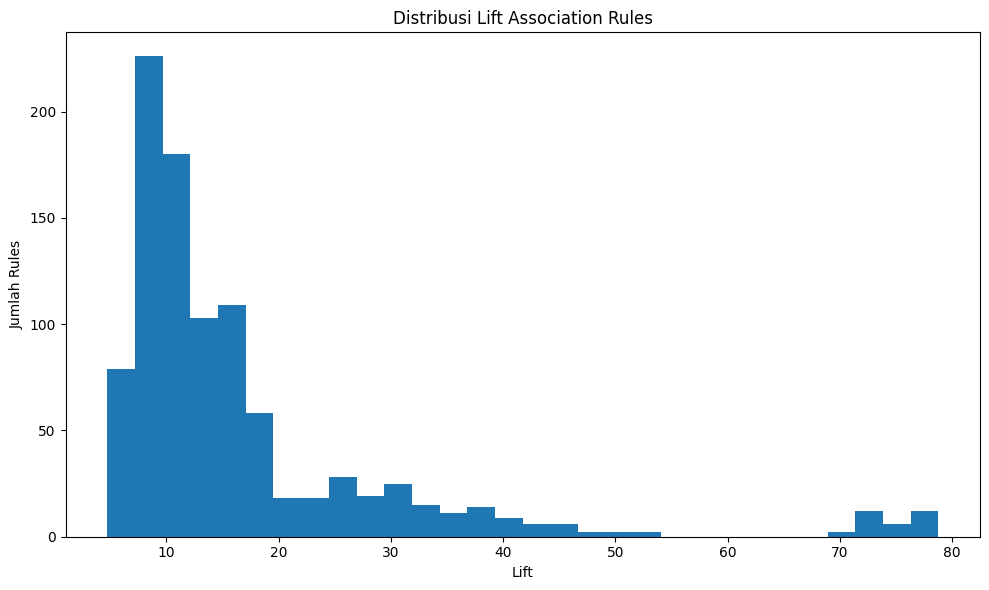

In [ ]:
# Distribusi Lift
plt.figure(figsize=(10, 6))

plt.hist(
    rules["lift"],
    bins=30
)

plt.title(
    "Distribusi Lift Association Rules"
)

plt.xlabel("Lift")
plt.ylabel("Jumlah Rules")

plt.tight_layout()
plt.show()

# **Uji Sensitivitas**

## 1. Pengaruh nilai minimum support
Model dijalankan ulang dengan beberapa nilai `min_support` untuk melihat pengaruhnya terhadap jumlah frequent itemset dan rules (confidence dan lift tetap).

In [ ]:
sensitivity = []

for ms in [0.02, 0.015, 0.01, 0.0075]:
    fi = fpgrowth(basket, min_support=ms, use_colnames=True)
    if len(fi) == 0:
        n_rules = 0
    else:
        r = association_rules(fi, metric="confidence", min_threshold=MIN_CONFIDENCE)
        n_rules = int((r["lift"] > 1).sum())
    sensitivity.append({
        "min_support": ms,
        "min_invoice": int(np.ceil(ms * len(basket))),
        "frequent_itemsets": len(fi),
        "rules": n_rules,
    })

sensitivity_df = pd.DataFrame(sensitivity)
sensitivity_df

,min_support,min_invoice,frequent_itemsets,rules
0,0.0200,396,395,61
1,0.0150,297,763,215
2,0.0100,198,2026,962
3,0.0075,149,4568,3688


## 2. Pengaruh invoice dengan basket ekstrem
Model dijalankan ulang tanpa invoice di atas persentil 99, lalu jumlah rules dan rules teratasnya dibandingkan dengan model utama.

In [ ]:
basket_trim = basket.loc[~basket.index.isin(large_invoices)]

fi_trim = fpgrowth(basket_trim, min_support=MIN_SUPPORT, use_colnames=True)
rules_trim = association_rules(fi_trim, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules_trim = rules_trim[rules_trim["lift"] > 1]

# Berapa rules model utama yang tetap muncul setelah invoice ekstrem dibuang
key = lambda df_: set(zip(df_["antecedents"], df_["consequents"]))
overlap = len(key(rules) & key(rules_trim))

print("Invoice dipakai (utama / tanpa P99):", len(basket), "/", len(basket_trim))
print("Rules (utama / tanpa P99)          :", len(rules), "/", len(rules_trim))
print(f"Rules utama yang tetap muncul      : {overlap} ({overlap / len(rules) * 100:.1f}%)")

Invoice dipakai (utama / tanpa P99): 19773 / 19576
Rules (utama / tanpa P99)          : 962 / 564
Rules utama yang tetap muncul      : 559 (58.1%)


**Cara membaca:** jika sebagian besar rules model utama tetap muncul setelah invoice ekstrem dibuang, berarti hasil analisis **stabil** dan tidak bergantung pada segelintir transaksi grosir.

In [ ]:
# Tandai rules yang tetap muncul di model tanpa P99
key_trim = set(zip(rules_trim["antecedents"], rules_trim["consequents"]))

rules_unique["robust"] = [
    (a, c) in key_trim
    for a, c in zip(rules_unique["antecedents"], rules_unique["consequents"])
]

print("Rules unik        :", len(rules_unique))
print("Rules unik robust :", rules_unique["robust"].sum())

# Rules teratas (lift) beserta status robust
rules_result_unique.assign(robust=rules_unique["robust"].values).head(15)

Rules unik        : 870
Rules unik robust : 506


,Antecedent_Code,Antecedent,Consequent_Code,Consequent,support,confidence,lift,robust
0,"22917, 22918","HERB MARKER ROSEMARY, HERB MARKER PARSLEY",22916,HERB MARKER THYME,0.010267,0.944186,78.773800,False
1,"22916, 22918","HERB MARKER THYME, HERB MARKER PARSLEY",22917,HERB MARKER ROSEMARY,0.010267,0.953052,78.519542,False
2,"22916, 22920","HERB MARKER THYME, HERB MARKER BASIL",22917,HERB MARKER ROSEMARY,0.010115,0.952381,78.464286,False
3,"22917, 22920","HERB MARKER ROSEMARY, HERB MARKER BASIL",22916,HERB MARKER THYME,0.010115,0.934579,77.972318,False
4,22916,HERB MARKER THYME,22917,HERB MARKER ROSEMARY,0.011177,0.932489,76.825475,True
5,"22916, 22917","HERB MARKER THYME, HERB MARKER ROSEMARY",22918,HERB MARKER PARSLEY,0.010267,0.918552,76.313149,False
6,22916,HERB MARKER THYME,22918,HERB MARKER PARSLEY,0.010772,0.898734,74.666684,True
7,22918,HERB MARKER PARSLEY,22917,HERB MARKER ROSEMARY,0.010873,0.903361,74.425683,True
8,"22916, 22917","HERB MARKER THYME, HERB MARKER ROSEMARY",22920,HERB MARKER BASIL,0.010115,0.904977,73.942635,False
9,22918,HERB MARKER PARSLEY,22919,HERB MARKER MINT,0.010722,0.890756,73.387185,True


In [ ]:
rr = rules_result_unique.assign(robust=rules_unique["robust"].values)
rr[rr["robust"]].head(15)

,Antecedent_Code,Antecedent,Consequent_Code,Consequent,support,confidence,lift,robust
4,22916,HERB MARKER THYME,22917,HERB MARKER ROSEMARY,0.011177,0.932489,76.825475,True
6,22916,HERB MARKER THYME,22918,HERB MARKER PARSLEY,0.010772,0.898734,74.666684,True
7,22918,HERB MARKER PARSLEY,22917,HERB MARKER ROSEMARY,0.010873,0.903361,74.425683,True
9,22918,HERB MARKER PARSLEY,22919,HERB MARKER MINT,0.010722,0.890756,73.387185,True
16,23172,REGENCY TEA PLATE PINK,"23170, 23171","REGENCY TEA PLATE ROSES, REGENCY TEA PLATE GREEN",0.012896,0.836066,51.822961,True
17,"23170, 23172","REGENCY TEA PLATE ROSES, REGENCY TEA PLATE PINK",23171,REGENCY TEA PLATE GREEN,0.012896,0.947955,49.196645,True
18,23172,REGENCY TEA PLATE PINK,23171,REGENCY TEA PLATE GREEN,0.014060,0.911475,47.303421,True
21,23174,REGENCY SUGAR BOWL GREEN,23175,REGENCY MILK JUG PINK,0.012289,0.754658,45.355198,True
22,"22745, 22748","POPPY'S PLAYHOUSE BEDROOM, POPPY'S PLAYHOUSE K...",22746,POPPY'S PLAYHOUSE LIVINGROOM,0.011329,0.715655,43.142211,True
25,21239,PINK POLKADOT CUP,21240,BLUE POLKADOT CUP,0.010519,0.677524,41.220586,True


# **Interpretasi Hasil**

> Angka pada bagian ini diambil dari hasil running dengan `MIN_SUPPORT = 0.01` dan `MIN_CONFIDENCE = 0.50`. Jika parameter atau cleaning diubah, sesuaikan kembali angkanya.

**1. Rules dengan lift tertinggi — produk satu seri.**
Rules teratas didominasi seri **HERB MARKER** (thyme, rosemary, parsley, basil, mint) dengan lift ±74–79 dan confidence hingga ±0,95. Contoh: pelanggan yang membeli *HERB MARKER THYME* dan *HERB MARKER PARSLEY* hampir selalu (95%) juga membeli *HERB MARKER ROSEMARY*. Lift setinggi ini berarti kombinasi tersebut muncul ±78 kali lebih sering daripada jika pembelian terjadi secara acak. Pola serupa terlihat pada **REGENCY TEA PLATE** (lift ±40–49) dan **WOODEN CHRISTMAS SCANDINAVIAN** (lift ±36). Namun support-nya rendah (±1%), sehingga cakupannya kecil.

**2. Rules dengan support tertinggi — produk populer.**
Rule dengan support terbesar adalah *JUMBO BAG PINK POLKADOT → JUMBO BAG RED RETROSPOT* (support ±4,2%, confidence ±0,68, lift ±6,4). *JUMBO BAG RED RETROSPOT* menjadi consequent bagi banyak varian jumbo bag lain, sehingga berperan sebagai produk "jangkar". Pasangan **REGENCY TEACUP AND SAUCER** (green–roses–pink) juga kuat dan sering muncul (support ±3–3,9%, lift ±14–18).

**3. Karakteristik umum.**
Mayoritas asosiasi yang kuat terjadi **di dalam satu koleksi/seri produk** (warna atau motif berbeda dari produk yang sama). Hal ini sesuai dengan karakter pelanggan yang didominasi pembeli grosir/reseller, yang cenderung membeli beberapa varian sekaligus. Asosiasi **lintas lini produk** lebih jarang dan umumnya memiliki lift yang lebih rendah (lihat tabel *Rules Lintas Lini Produk*).

# **Rekomendasi Bisnis**

1. **Bundling satu seri** — jual produk satu seri sebagai paket (misalnya paket HERB MARKER isi 4–6 varian, paket REGENCY TEACUP 3 warna, paket REGENCY TEA PLATE). Confidence >0,9 menunjukkan pelanggan memang cenderung membeli seluruh varian.
2. **Rekomendasi "Frequently Bought Together"** — saat pelanggan melihat salah satu varian (misalnya JUMBO BAG PINK POLKADOT), tampilkan varian lain yang paling sering dibeli bersamaan (JUMBO BAG RED RETROSPOT).
3. **Manajemen stok** — produk yang saling berasosiasi kuat sebaiknya direncanakan stoknya bersama-sama, karena kehabisan satu varian berpotensi menurunkan penjualan varian lainnya.
4. **Cross-selling lintas kategori** — gunakan rules pada tabel *Rules Lintas Lini Produk* untuk penempatan produk berdekatan di katalog/website dan untuk kampanye promosi.

# **Kesimpulan**

1. Setelah cleaning (menghapus deskripsi kosong, transaksi cancellation, harga ≤ 0, dan kode non-produk), diperoleh **527.759 baris** dari **19.773 invoice** dan **3.908 produk**, atau 97,39% dari data awal.
2. Algoritma FP-Growth dengan `min_support = 0.01` menghasilkan **2.007 frequent itemset** (ukuran 1–5 item). Dengan `min_confidence = 0.5` dan `lift > 1` dihasilkan **956 association rules**, yang setelah menghapus rules dobel menjadi jumlah seperti ditampilkan pada bagian *Menghapus Rules Dobel*.
3. Asosiasi terkuat terjadi antar varian dalam satu seri produk (HERB MARKER, REGENCY TEACUP/TEA PLATE, JUMBO BAG), sehingga strategi yang paling relevan adalah **bundling** dan **rekomendasi varian**.
4. Keterbatasan: data didominasi transaksi dari UK dan pembeli grosir, data Desember 2011 tidak lengkap, dan rules hanya menunjukkan asosiasi, bukan hubungan sebab-akibat.

# **Export Hasil**

In [ ]:
rules_result.to_csv("association_rules_all.csv", index=False)
rules_result_unique.to_csv("association_rules_unique.csv", index=False)
cross_line_rules.to_csv("association_rules_cross_line.csv", index=False)
frequent_itemsets.assign(
    itemsets=frequent_itemsets["itemsets"].apply(itemset_to_code),
    description=frequent_itemsets["itemsets"].apply(itemset_to_description),
).to_csv("frequent_itemsets.csv", index=False)

print("File hasil tersimpan.")